In [ ]:
# Install and import required libraries
!pip install datasets
import torch
import os
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision import datasets,models
from torch.utils.data import DataLoader,random_split
from torch.utils.data import Dataset
from skimage import io,transform
from PIL import Image
from datasets import load_dataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load dataset from Huggingface
brain_dataset_train = load_dataset('Falah/Alzheimer_MRI', split = 'train')
brain_dataset_test = load_dataset('Falah/Alzheimer_MRI', split = 'test')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Apply transformations to the dataset
image_to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

brain_dataset_train.set_transform(lambda example: {'image': [image_to_tensor(img) for img in example['image']], 'label': example['label']})
brain_dataset_test.set_transform(lambda example: {'image': [image_to_tensor(img) for img in example['image']], 'label': example['label']})

# Create dataloaders for training and testing
train_dataloader = DataLoader(brain_dataset_train,batch_size = 32, shuffle = True)
test_dataloader = DataLoader(brain_dataset_test,batch_size = 32, shuffle = False)

In [ ]:
# Number of output classes
num_classes = 4

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("using:", device)

# Load pretrained EfficientNet-B7
model = torchvision.models.efficientnet_b7(weights='EfficientNet_B7_Weights.IMAGENET1K_V1')
in_feature = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(p=0.5, inplace=True), nn.Linear(in_feature, num_classes))
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

using  cuda


In [ ]:
# Training loop (runs for 5 epochs)
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

# Loop through training batches
    for batch in train_dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

# Print epoch loss
    epoch_loss = running_loss / len(train_dataloader)
    print(f"EfficientNet_B7 Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Print training complete message
print("Training Complete for EfficientNet_B7")

EfficientNet_B7 Epoch 1/5, Loss: 0.2584
EfficientNet_B7 Epoch 2/5, Loss: 0.1530
EfficientNet_B7 Epoch 3/5, Loss: 0.0895
EfficientNet_B7 Epoch 4/5, Loss: 0.0778
EfficientNet_B7 Epoch 5/5, Loss: 0.0656
Training Complete for EfficientNet_B7


--------EfficientNet_B7----------

Accuracy:  0.965625
Balanced Accuracy:  0.9591408028988133
Precision 0.9662531305312125

Classification Report: 
                     precision    recall  f1-score   support

     Mild_Demented       0.96      0.90      0.93       172
 Moderate_Demented       1.00      0.73      0.85        15
      Non_Demented       0.85      1.00      0.92       634
Very_Mild_Demented       0.97      0.78      0.86       459

          accuracy                           0.90      1280
         macro avg       0.95      0.85      0.89      1280
      weighted avg       0.91      0.90      0.90      1280



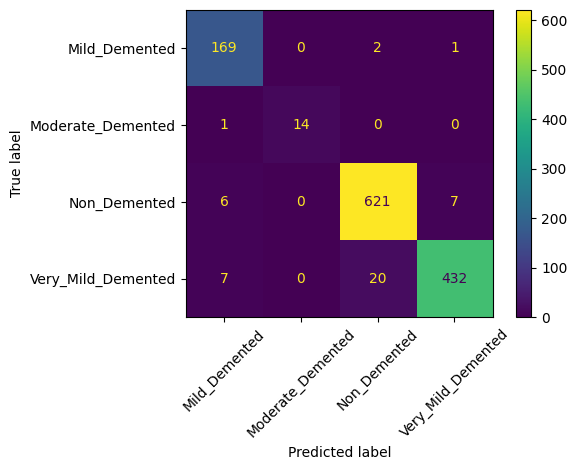

In [ ]:
# Import metrics for evaluation
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate model on test data
model.eval()
all_preds = []
all_labels = []

# Loop through test set
with torch.no_grad():
    for batch in test_dataloader:

        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(images)


        _, predicted = torch.max(outputs, 1);

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print metrics (accuracy, balanced accuracy, precision, report)
print("--------EfficientNet_B7----------\n")
print("Accuracy: ", accuracy_score(all_labels, all_preds))
print("Balanced Accuracy: ", balanced_accuracy_score(all_labels, all_preds))
print("Precision", precision_score(all_labels, all_preds,
                                  average='weighted', zero_division=0))
print("\nClassification Report: \n", classification_report(all_labels, all_preds,
                                                          zero_division=0, labels=list(range(num_classes)), target_names=['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']))

# Confusion matrix visualization
cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented'])
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()